In [2]:
import sys
sys.path.append('..')
import torch
import pandas as pd
import numpy as np
import pickle
import argparse
import networkx as nx
from torch_geometric.utils import dense_to_sparse, degree
import matplotlib.pyplot as plt
from src.gcn import GCNSynthetic
from src.utils.utils import normalize_adj, get_neighbourhood

### Syn4 dataset (tree cycles) , best params so far: SGD with epochs=500, LR=0.1, beta=0.5

#### Uses correct version of symmetry constraint

#### For tree-cycles, class 0 = base tree, class 1 = cycle

In [3]:
header = ["node_idx", "new_idx", "cf_adj", "sub_adj", "y_pred_orig", "y_pred_new", "y_pred_new_actual",
            "label", "num_nodes", "loss_total", "loss_pred", "loss_graph_dist"]

In [4]:
# For original model
dataset = "syn4"
hidden = 20
seed = 42
dropout = 0.0

# Load original dataset and model

with open("../data/gnn_explainer/{}.pickle".format(dataset), "rb") as f:
	data = pickle.load(f)

adj = torch.Tensor(data["adj"]).squeeze()       # Does not include self loops
features = torch.Tensor(data["feat"]).squeeze()
labels = torch.tensor(data["labels"]).squeeze()
idx_train = torch.tensor(data["train_idx"])
idx_test = torch.tensor(data["test_idx"])
edge_index, _ = dense_to_sparse(adj)

norm_adj = normalize_adj(adj)

model = GCNSynthetic(nfeat=features.shape[1], nhid=hidden, nout=hidden,
                     nclass=len(labels.unique()), dropout=dropout)
model.load_state_dict(torch.load("../models/gcn_3layer_{}.pt".format(dataset)))
model.eval()
output = model(features, norm_adj)
y_pred_orig = torch.argmax(output, dim=1)
print("test set y_true counts: {}".format(np.unique(labels[idx_test].numpy(), return_counts=True)))
print("test set y_pred_orig counts: {}".format(np.unique(y_pred_orig[idx_test].numpy(), return_counts=True)))
print("Whole graph counts: {}".format(np.unique(labels.numpy(), return_counts=True)))

test set y_true counts: (array([0, 1]), array([96, 79]))
test set y_pred_orig counts: (array([0, 1]), array([94, 81]))
Whole graph counts: (array([0, 1]), array([511, 360]))


In [5]:
lr = 0.1
beta = 0.5
num_epochs = 500

# Load cf examples for test set
with open("../results/{}/SGD/{}_cf_examples_lr{}_beta{}_mom0.0_epochs{}_seed42".format(dataset,
                                                                     dataset,lr,beta, num_epochs), "rb") as f:
    cf_examples = pickle.load(f)
    
df_prep = []
for example in cf_examples:
    if example != []:
        df_prep.append(example[0])
df = pd.DataFrame(df_prep, columns=header)

print("ALL CF EXAMPLES")
print("Num cf examples found: {}/{}".format(len(df), len(idx_test)))
print("Average graph distance: {}".format(np.mean(df["loss_graph_dist"])))

df.head()

ALL CF EXAMPLES
Num cf examples found: 139/175
Average graph distance: 2.093525179856115


,node_idx,new_idx,cf_adj,sub_adj,y_pred_orig,y_pred_new,y_pred_new_actual,label,num_nodes,loss_total,loss_pred,loss_graph_dist
0,161,8,"[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,1,1,0,22,1.5,-1.199472,3.0
1,187,6,"[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,1,1,0,19,0.5,-1.675234,1.0
2,92,7,"[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,1,1,0,30,4.0,-2.896294,8.0
3,228,7,"[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,1,1,0,28,0.5,-1.468810,1.0
4,68,7,"[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,1,1,0,26,3.5,-3.162936,7.0


In [6]:
# Add num edges to df

num_edges = []
for i in df.index:
    num_edges.append(sum(sum(df["sub_adj"][i]))/2)

df["num_edges"] = num_edges

### FINAL NUMBERS

In [7]:
print("Num cf examples found: {}/{}".format(len(df), len(idx_test)))
print("Coverage: {}".format(len(df)/len(idx_test)))
print("Average graph distance: {}".format(np.mean(df["loss_graph_dist"])))
print("Average prop comp graph perturbed: {}".format(np.mean(df["loss_graph_dist"]/df["num_edges"])))

Num cf examples found: 139/175
Coverage: 0.7942857142857143
Average graph distance: 2.093525179856115
Average prop comp graph perturbed: 0.1032092855899766


Text(0, 0.5, 'Prop CF examples')

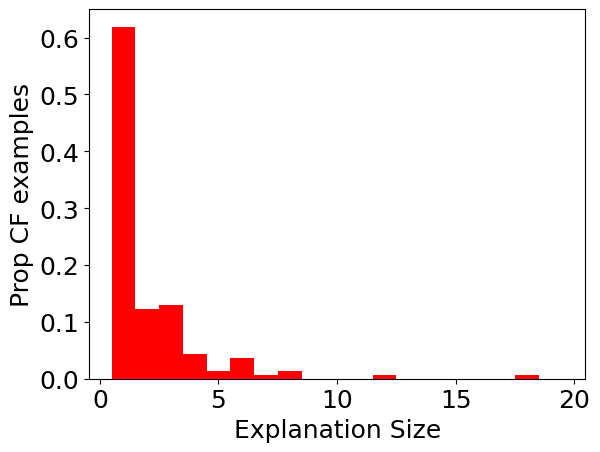

In [8]:
font = {'weight' : 'normal',
        'size'   : 18}

plt.rc('font', **font)

# Plot graph loss of cf examples
bins = [i+0.5 for i in range(20)]
plt.hist(df["loss_graph_dist"],  bins=bins,color='r', weights=np.ones(len(df))/len(df))
plt.xticks([0, 5, 10, 15, 20])
plt.ylim(0, 0.65)
plt.xlabel("Explanation Size")
plt.ylabel("Prop CF examples")

In [9]:
# For accuracy, only look at motif nodes

df_motif = df[df["y_pred_orig"] != 0].reset_index(drop=True)

accuracy = []

# Get original predictions 
dict_ypred_orig = dict(zip(sorted(np.concatenate((idx_train.numpy(), idx_test.numpy()))), 
                           y_pred_orig.numpy()))

for i in range(len(df_motif)):
    node_idx = df_motif["node_idx"][i]
    new_idx = df_motif["new_idx"][i]

    _, _, _, node_dict = get_neighbourhood(int(node_idx), edge_index, 4, features, labels)

    # Confirm idx mapping is correct
    if node_dict[node_idx] == df_motif["new_idx"][i]:

        cf_adj = df_motif["cf_adj"][i]
        sub_adj = df_motif["sub_adj"][i]
        perturb = np.abs(cf_adj - sub_adj)
        perturb_edges = np.nonzero(perturb)        # Edge indices

        nodes_involved = np.unique(np.concatenate((perturb_edges[0], perturb_edges[1]), axis=0))
        perturb_nodes = nodes_involved[nodes_involved != new_idx]   # Remove original node

        # Retrieve original node idxs for original predictions
        perturb_nodes_orig_idx = []
        for j in perturb_nodes:
            perturb_nodes_orig_idx.append([key for (key, value) in node_dict.items() if value == j])
        perturb_nodes_orig_idx = np.array(perturb_nodes_orig_idx).flatten()

        # Retrieve original predictions
        perturb_nodes_orig_ypred = np.array([dict_ypred_orig[k] for k in perturb_nodes_orig_idx])
        nodes_in_motif = perturb_nodes_orig_ypred[perturb_nodes_orig_ypred != 0]
        prop_correct = len(nodes_in_motif)/len(perturb_nodes_orig_idx)

        accuracy.append([node_idx, new_idx, perturb_nodes_orig_idx, 
                        perturb_nodes_orig_ypred, nodes_in_motif, prop_correct])

df_accuracy = pd.DataFrame(accuracy, columns=["node_idx", "new_idx", "perturb_nodes_orig_idx", 
                        "perturb_nodes_orig_ypred", "nodes_in_motif", "prop_correct"])



print("Accuracy", np.mean(df_accuracy["prop_correct"]))

Accuracy 0.9444444444444444


### Dataset statistics

In [10]:
# Get full dataset statistics

full_dataset = pd.DataFrame()

idx_concat = torch.cat((idx_train, idx_test), 0)
full_dataset["node_idx"] = idx_concat
full_dataset["y_pred_orig"] = y_pred_orig[idx_concat]
full_dataset["label"] = labels[idx_concat]
full_dataset["node_degree"] = torch.sum(adj[idx_concat], dim=1).numpy()


num_nodes = []
sub_adj = []
sub_labels = []
for i in full_dataset["node_idx"]:
    sub_adj0, _, sub_labels0, node_dict = get_neighbourhood(i,edge_index,4,
                                         features,labels)

    num_nodes.append(sub_adj0.shape[0])
    
    # Need these for plotting later
    sub_adj.append(sub_adj0.numpy())
#     sub_labels.append(sub_labels0.numpy())
    
full_dataset["num_nodes"] = num_nodes
full_dataset["sub_adj"] = sub_adj


# Add num edges in computational graph
num_edges = []
for i in full_dataset.index:
    num_edges.append(sum(sum(full_dataset["sub_adj"][i]))/2)

full_dataset["num_edges"] = num_edges

full_dataset.head()

print("Avg node degree: ", np.mean(full_dataset["node_degree"]))
print("Avg num nodes in computational graph: ", np.mean(full_dataset["num_nodes"]))
print("Avg num edges in computational graph: ", np.mean(full_dataset["num_edges"]))

Avg node degree:  2.227325
Avg num nodes in computational graph:  19.121699196326063
Avg num edges in computational graph:  18.991963260619976
